# Generic TIF inspection

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [57]:
import os
import re
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import glob
from usnm2p.bergamo_utils import stack_scanimage_singleframe_tifs
from usnm2p.parsers import parse_scanimage_metadata_from_tif_tags
from usnm2p.fileops import loadtif, load_tif_nframes, load_scanimage_metadata, print_scanimage_metadata, load_scanimage_nchannels
from usnm2p.viewers import view_stack

### Inputs

In [32]:
dataroot = '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/'

In [79]:
stack_dir = os.path.join(dataroot)
stack_fpaths = sorted(glob.glob(os.path.join(stack_dir, '*.tif')))
stack_fnames = [os.path.basename(f) for f in stack_fpaths]

In [78]:
run_fpaths

['/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00001.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00002.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00003.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00004.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00005.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00006.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100

In [76]:
# Extract trial stacks for particular run
runpattern = '100Hz_200ms_30Hz_08MPa_50DC_run01'
run_fpaths = [f for f in stack_fpaths if runpattern in f]

# Extract number of frames from each file
pattern = re.compile(r'^crevip_(\d{3})frames_(.*).tif$')
for fpath in run_fpaths:
    fname = os.path.basename(fpath)
    mo = pattern.match(fname)
    if mo:
        nframes, suffix = mo.groups()
        nframes = int(nframes)

        # If number of frames is not 450
        if nframes != 450:
            print('xxxx')

        #     # Load TIF data and metadata
        #     data, si_meta = loadtif(fpath, metadata=True, verbose=False)

        #     # Load SI metadata
        #     tags = tifffile.TiffFile(fpath).pages[0].tags
        #     desc = tags['ImageDescription'].value
        #     software = tags['Software'].value
        #     compression = tags['Compression'].value

        #     tags_to_add = [
        #         'Orientation',
        #         'Artist',
        #     ]
        #     extratags = [tag.astuple() for tag_id, tag in tags.items() if tag.name in tags_to_add]

        #     # Cut it to first 450 frames
        #     stack = stack[:450]
        #     # Save corrected TIF with new filename
        #     new_fname = f'crevip_450frames_{suffix}.tif'
        #     print(f'correcting {fname} -> {new_fname}')
        #     new_fpath = os.path.join(stack_dir, new_fname)
        #     print(new_fpath)
        #     tifffile.imwrite(
        #         new_fpath, 
        #         stack, 
        #         description=desc, 
        #         software=software,
        #         compression=compression,
        #         extratags=extratags
        #     )
        #     # tifffile.imwrite(new_fpath, stack)
        # # sorted_run_fpaths[trial - 1] = fpath

sorted_run_fpaths

['/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00001.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00002.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00003.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00004.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00005.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00006.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_750frames_100

In [81]:
# Extract trial stacks for particular run
runpattern = '100Hz_200ms_30Hz_08MPa_50DC_run01'
run_fpaths = [f for f in stack_fpaths if runpattern in f]
run_fpaths

['/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00001.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00002.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00003.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00004.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00005.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00006.tif',
 '/gpfs/scratch/lemait01/data/usnm/raw_bergamo/main/cre_vip/20200309_mouse214_region1/crevip_450frames_100

In [82]:
view_stack(sorted_run_fpaths[0], nchannels=2, merge_channels=False, rel_vbounds=(0, 0.7))

 2025/11/20 14:58:10: initializing 2-channel stack viewer
 2025/11/20 14:58:10: stack size: (450, 512, 512)
 2025/11/20 14:58:10: computing stack dynamic range across frames 0 - 449...
 2025/11/20 14:58:10: computing frame-average metrics across frames 0 - 449...


100%|██████████| 450/450 [00:01<00:00, 359.72it/s]

 2025/11/20 14:58:11: stack dynamic range range: -4 - 769
 2025/11/20 14:58:11: computing stack dynamic range across frames 0 - 449...
 2025/11/20 14:58:11: computing frame-average metrics across frames 0 - 449...



100%|██████████| 450/450 [00:01<00:00, 399.16it/s]

 2025/11/20 14:58:12: stack dynamic range range: -11 - 281
 2025/11/20 14:58:12: rendering stack view...


In [83]:
# Compute frame average profiles for each stack
Favgs = []
for itrial, fpath in enumerate(sorted_run_fpaths):
    stack = loadtif(fpath)
    Favg = stack[:, 0].mean(axis=(1, 2))
    Favgs.append(Favg)

 2025/11/20 14:58:14: loading data from crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00001.tif
 2025/11/20 14:58:15: inferring number of channels from ScanImage metadata
 2025/11/20 14:58:15: loaded (450, 2, 512, 512) int16 stack
 2025/11/20 14:58:15: loading data from crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00002.tif
 2025/11/20 14:58:15: inferring number of channels from ScanImage metadata
 2025/11/20 14:58:15: loaded (450, 2, 512, 512) int16 stack
 2025/11/20 14:58:15: loading data from crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00003.tif
 2025/11/20 14:58:15: inferring number of channels from ScanImage metadata
 2025/11/20 14:58:15: loaded (450, 2, 512, 512) int16 stack
 2025/11/20 14:58:15: loading data from crevip_450frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00004.tif
 2025/11/20 14:58:16: inferring number of channels from ScanImage metadata
 2025/11/20 14:58:16: loaded (450, 2, 512, 512) int16 stack
 2025/11/20 14:58:16: loading data from crevip_450frames

In [ ]:
fs = 30 # Hz
tstim = 5.0 # seconds

150

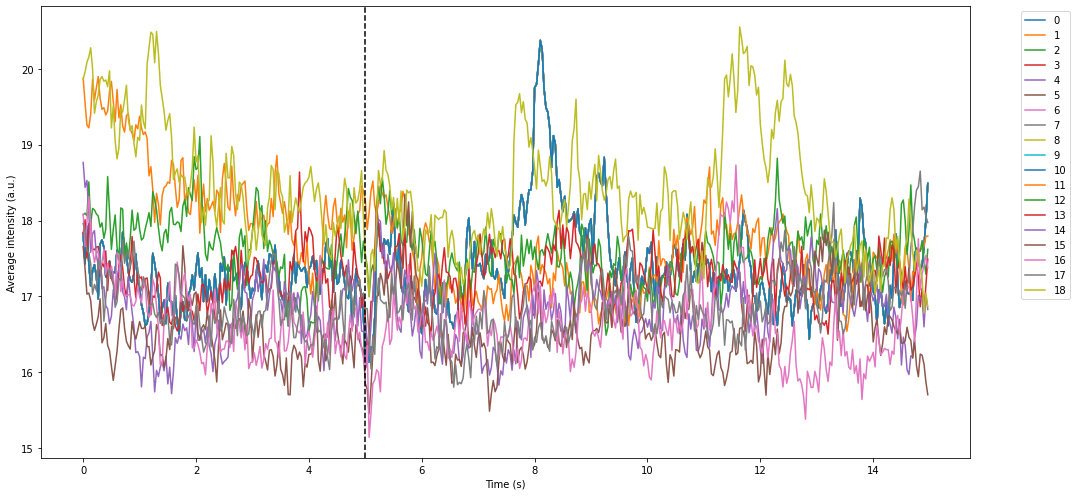

In [84]:
fig, ax = plt.subplots(figsize=(15, 7)) 
for itrial, Favg in enumerate(Favgs):
    ax.plot(np.arange(len(Favg)) / fs, Favg, label=itrial)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Average intensity (a.u.)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axvline(tstim, color='k', linestyle='--', label='Stimulus')
fig.tight_layout()

In [47]:
view_stack(sorted_run_fpaths[-1], nchannels=2, merge_channels=False, rel_vbounds=(0, 0.7))

 2025/11/20 14:30:32: initializing 2-channel stack viewer
 2025/11/20 14:30:32: stack size: (450, 512, 512)
 2025/11/20 14:30:32: computing stack dynamic range across frames 0 - 449...
 2025/11/20 14:30:32: computing frame-average metrics across frames 0 - 449...


100%|██████████| 450/450 [00:02<00:00, 206.12it/s]

 2025/11/20 14:30:34: stack dynamic range range: -4 - 1362
 2025/11/20 14:30:34: computing stack dynamic range across frames 0 - 449...
 2025/11/20 14:30:34: computing frame-average metrics across frames 0 - 449...



100%|██████████| 450/450 [00:02<00:00, 205.46it/s]

 2025/11/20 14:30:36: stack dynamic range range: -10 - 366
 2025/11/20 14:30:36: rendering stack view...


In [34]:
print(f'extracting frames and channels from {len(stack_fpaths)} files...')
df = {}
for f in tqdm(stack_fpaths):
    # Extract number of channels and number of frames per channel
    nchannels = load_scanimage_nchannels(f)
    nframes = load_tif_nframes(f, nchannels=nchannels)
 
    df[os.path.basename(f)] = pd.Series({'nchannels': nchannels, 'nframes':  nframes})

df = pd.concat(df, axis=1, names=['filename']).T
df

  0%|          | 0/180 [00:00<?, ?it/s]

extracting frames and channels from 180 files...


100%|██████████| 180/180 [00:35<00:00,  5.10it/s]


,nchannels,nframes
filename,,
crevip_357frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00020.tif,2,357
crevip_450frames_100Hz_200ms_30Hz_00MPa_50DC_run11_00001.tif,2,450
crevip_450frames_100Hz_200ms_30Hz_00MPa_50DC_run11_00002.tif,2,450
crevip_450frames_100Hz_200ms_30Hz_00MPa_50DC_run11_00003.tif,2,450
crevip_450frames_100Hz_200ms_30Hz_00MPa_50DC_run11_00004.tif,2,450
...,...,...
crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00007.tif,2,750
crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00008.tif,2,750
crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00009.tif,2,750


In [35]:
df['nframes'].value_counts()

nframes
450    168
750     11
357      1
Name: count, dtype: int64

### Normal ScanImage TIF stack

In [74]:
input_fname = '20200309_VIP214_08MPa_5DC_00006.tif'
input_fname = 'crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00005.tif'
input_fpath = os.path.join(dataroot, input_fname)
stack, meta = loadtif(input_fpath, metadata=True)
view_stack(input_fpath, nchannels=2, merge_channels=False, rel_vbounds=(0, 0.7))

 2025/11/14 13:31:07: loading data from crevip_750frames_100Hz_200ms_30Hz_08MPa_50DC_run01_00005.tif
 2025/11/14 13:31:08: inferring number of channels from ScanImage metadata
 2025/11/14 13:31:08: loaded (750, 2, 512, 512) int16 stack
 2025/11/14 13:31:08: initializing 2-channel stack viewer
 2025/11/14 13:31:08: stack size: (750, 512, 512)
 2025/11/14 13:31:08: computing stack dynamic range across frames 0 - 749...
 2025/11/14 13:31:08: computing frame-average metrics across frames 0 - 749...


100%|██████████| 750/750 [00:02<00:00, 286.28it/s]

 2025/11/14 13:31:11: stack dynamic range range: -8 - 1371
 2025/11/14 13:31:11: computing stack dynamic range across frames 0 - 749...
 2025/11/14 13:31:11: computing frame-average metrics across frames 0 - 749...



100%|██████████| 750/750 [00:02<00:00, 289.10it/s]

 2025/11/14 13:31:14: stack dynamic range range: -9 - 405
 2025/11/14 13:31:14: rendering stack view...


### Stack of single-frame ScanImage TIFs

In [69]:
input_dir = os.path.join(dataroot, 'singleframe')
input_fpaths = sorted(glob.glob(os.path.join(input_dir, '20200309_VIP214_01MPa_50DC_00003_*.tif')))
output_fpath = stack_scanimage_singleframe_tifs(input_fpaths, overwrite=True)
stack, meta = loadtif(output_fpath, metadata=True)
view_stack(output_fpath, nchannels=2, merge_channels=False, rel_vbounds=(0, 0.7))

 2025/11/14 12:07:45: stacking 450 single-frame TIFs into 20200309_VIP214_01MPa_50DC_00003.tif


100%|██████████| 450/450 [00:02<00:00, 165.57it/s]


 2025/11/14 12:07:48: loading data from 20200309_VIP214_01MPa_50DC_00003.tif
 2025/11/14 12:07:49: inferring number of channels from ScanImage metadata
 2025/11/14 12:07:49: splitting 2 channels (900, 512, 512) shaped array
 2025/11/14 12:07:49: loaded (450, 2, 512, 512) int16 stack
 2025/11/14 12:07:49: initializing 2-channel stack viewer
 2025/11/14 12:07:49: stack size: (450, 512, 512)
 2025/11/14 12:07:49: computing stack dynamic range across frames 0 - 449...
 2025/11/14 12:07:49: computing frame-average metrics across frames 0 - 449...


100%|██████████| 450/450 [00:01<00:00, 408.00it/s]

 2025/11/14 12:07:50: stack dynamic range range: -4 - 965
 2025/11/14 12:07:50: computing stack dynamic range across frames 0 - 449...
 2025/11/14 12:07:50: computing frame-average metrics across frames 0 - 449...



100%|██████████| 450/450 [00:01<00:00, 410.52it/s]

 2025/11/14 12:07:51: stack dynamic range range: -10 - 253
 2025/11/14 12:07:51: rendering stack view...
